# Day 5 — Full EDA Notebook - Streaming Platform Dataset Analysis


    This notebook contains complete EDA; descriptive statistics, univariate distributions, outlier handling, bivariate relationships and correlation analysis.
    
    The dataset that will be analysed is a streaming platform (Twitch) dataset.

In [43]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
import seaborn.objects as so
import numpy as np

Seaborn, Pandas, Matplotlib and NumPy libraries imported.

In [44]:
twitch = pd.read_csv("twitchdata.csv")
twitch

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English
...,...,...,...,...,...,...,...,...,...,...,...
995,LITkillah,122524635,13560,21359,9104,601927,562691,2162107,True,False,Spanish
996,빅헤드 (bighead033),122523705,153000,3940,793,213212,52289,4399897,True,False,Korean
997,마스카 (newmasca),122452320,217410,6431,567,109068,-4942,3417970,True,False,Korean
998,AndyMilonakis,122311065,104745,10543,1153,547446,109111,3926918,True,False,English


Dataset converted into a DataFrame using pandas' function .read_csv()

### Descriptive Statistics:

- In this section you will find:
   - measures of center
   - measures of spread

In [45]:
twitch = pd.read_csv("twitchdata.csv")
numeric_cols = ["Watch time(Minutes)", "Stream time(minutes)", "Peak viewers",
                 "Average viewers", "Followers", "Followers gained", "Views gained"]

summary = twitch[numeric_cols].agg(["mean", "median", lambda x: x.mode().iloc[0], "std", "min", "max"]).T
summary["IQR"] = twitch[numeric_cols].quantile(0.75) - twitch[numeric_cols].quantile(0.25)
summary.columns = ["mean", "median", "mode", "std", "min", "max", "IQR"]
summary.round(0)

,mean,median,mode,std,min,max,IQR
Watch time(Minutes),418427930.0,234990788.0,122192850.0,549635514.0,122192850.0,6.196162e+09,270550024.0
Stream time(minutes),120515.0,108240.0,51600.0,85376.0,3465.0,5.214450e+05,68085.0
Peak viewers,37065.0,16676.0,3940.0,60314.0,496.0,6.393750e+05,28456.0
Average viewers,4781.0,2425.0,1205.0,8454.0,235.0,1.476430e+05,3328.0
Followers,570054.0,318063.0,3660.0,804413.0,3660.0,8.938903e+06,453786.0
Followers gained,205519.0,98352.0,74894.0,339914.0,-15772.0,3.966525e+06,192372.0
Views gained,11668166.0,6456324.0,175788.0,24905722.0,175788.0,6.701375e+08,8316160.0


- Findings:
  - The mode is note a resistive measure of center in this case and is uninformative to use due to returning an arbitrary single value.

### Univariate Analysis:

In [46]:
print("(Rows x Columns):", twitch.shape)

(Rows x Columns): (1000, 11)


In [47]:
print("Data types:")
twitch.dtypes

Data types:


Channel                 object
Watch time(Minutes)      int64
Stream time(minutes)     int64
Peak viewers             int64
Average viewers          int64
Followers                int64
Followers gained         int64
Views gained             int64
Partnered                 bool
Mature                    bool
Language                object
dtype: object

In [48]:
print("Number of unique vlues per column:")
twitch.nunique()

Number of unique vlues per column:


Channel                 1000
Watch time(Minutes)     1000
Stream time(minutes)     962
Peak viewers             990
Average viewers          926
Followers               1000
Followers gained         998
Views gained            1000
Partnered                  2
Mature                     2
Language                  21
dtype: int64

In [49]:
print("Null values per column:")
twitch.isnull().sum()

Null values per column:


Channel                 0
Watch time(Minutes)     0
Stream time(minutes)    0
Peak viewers            0
Average viewers         0
Followers               0
Followers gained        0
Views gained            0
Partnered               0
Mature                  0
Language                0
dtype: int64

In [50]:
print("Numeric data skew:")
skew = twitch[numeric_cols].skew().sort_values(ascending=False)
skew

Numeric data skew:


Views gained            19.085191
Average viewers          9.066586
Followers gained         5.342437
Watch time(Minutes)      5.165895
Followers                4.549879
Peak viewers             4.528788
Stream time(minutes)     2.598804
dtype: float64

- Findings:
  - Views gained and average viewres are extremely right-skewed making the median and IQR much suitable measures of center and spread.

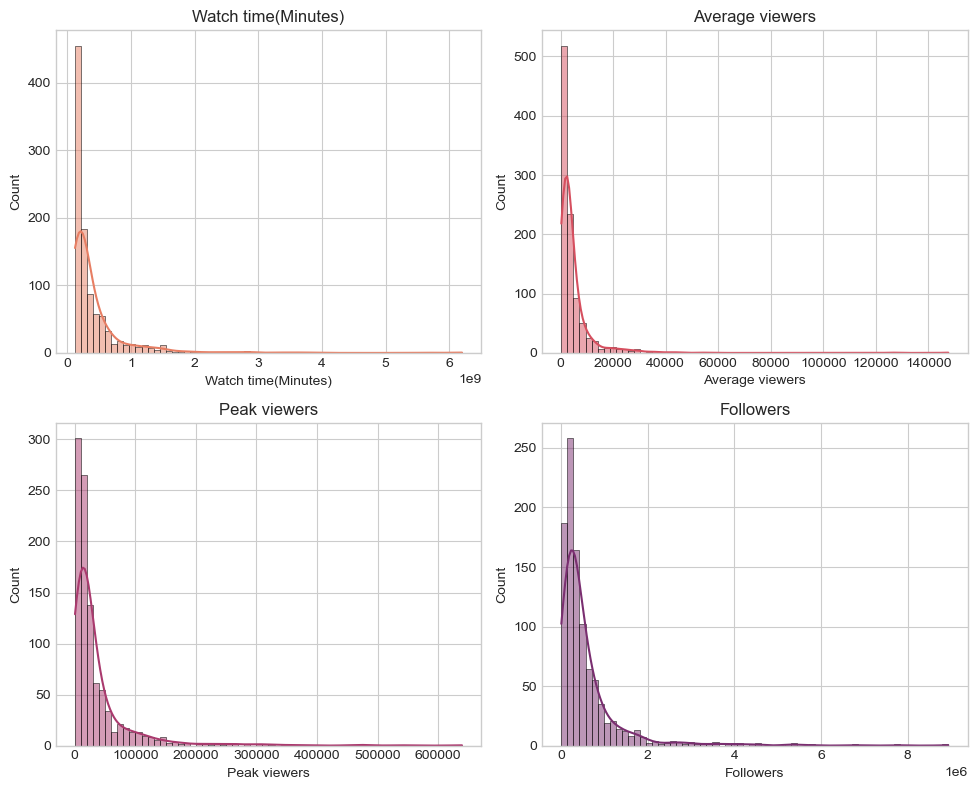

In [51]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
sns.histplot(twitch["Watch time(Minutes)"], kde= True, ax=axes[0,0], color="#e77e63")
sns.histplot(twitch["Average viewers"], kde= True, ax=axes[0,1], color="#d64f5f")
sns.histplot(twitch["Peak viewers"], kde= True, ax=axes[1,0], color="#aa3a6e")
sns.histplot(twitch["Followers"], kde= True, ax=axes[1,1], color="#7a2e70")

axes[0,0].set_title("Watch time(Minutes)")
axes[0,1].set_title("Average viewers")
axes[1,0].set_title("Peak viewers")
axes[1,1].set_title("Followers")

plt.tight_layout()
plt.show()

- Histogram Analysis:
    - All plots are extremely right skewed validating previously computed skew values.
    - This right skew is however due to outlires.
    - A few viral streamers show dominate total watch time, overall views and followers.

### Outlier detection:

In [52]:


for col in numeric_cols:
    q1 = twitch[col].quantile(0.25)
    q3 = twitch[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    up = q3 + 1.5 * iqr
    twitch[f"{col} outliers"] = (twitch[col].values < low) | (twitch[col].values > up)

twitch.filter(like=" outliers").sum()

Watch time(Minutes) outliers     107
Stream time(minutes) outliers     48
Peak viewers outliers            113
Average viewers outliers         100
Followers outliers                89
Followers gained outliers         90
Views gained outliers             91
dtype: int64

- Outliers Analysis:
    - From the above calculations, most columns have 90+ outliers, that is almost 10% of the overall data.
    - 10% is relatively a large proportion  of the data, however, they represent legitimate data values achieved by successful, hard working streamers rather than being erroneous values and for that reason they will be kept.

## Step 1 - Bivariate and Multivariate Analysis

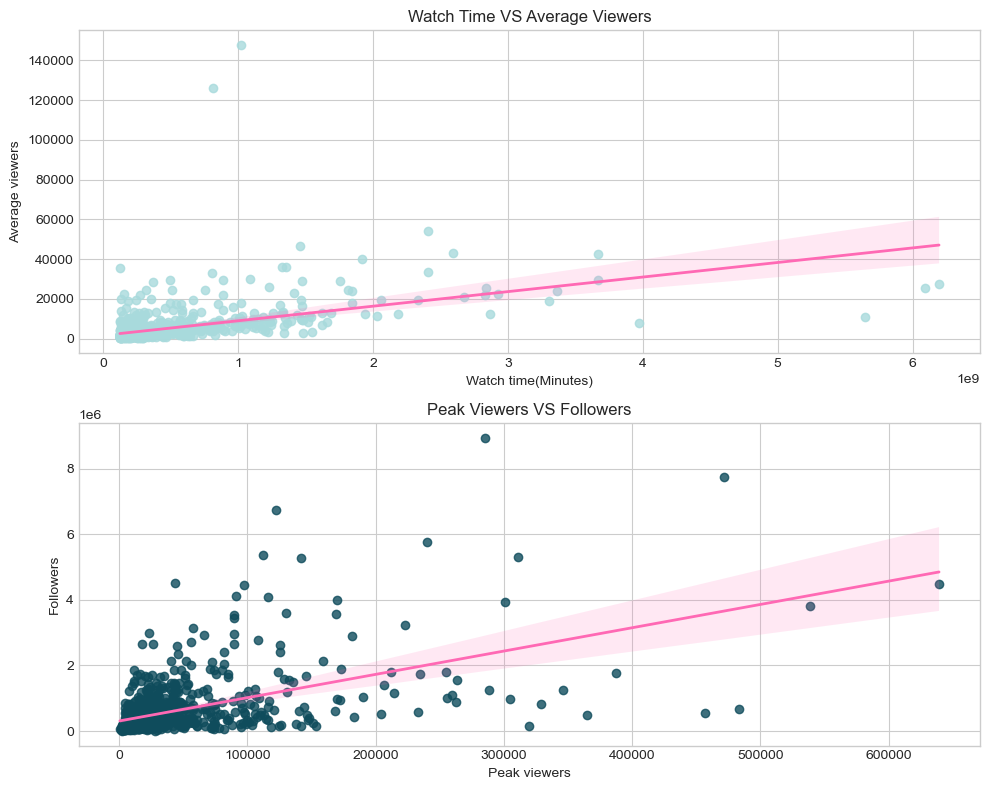

In [53]:
fig, axes = plt.subplots(2,1, figsize=(10,8))
sns.regplot(data=twitch, x="Watch time(Minutes)", y="Average viewers", ax=axes[0], color="#a8dadc", 
           line_kws={"color": "hotpink", "lw":2})
sns.regplot(data=twitch, x="Peak viewers", y="Followers", ax=axes[1], color="#0f4c5c",
               line_kws={"color": "hotpink", "lw":2})
axes[0].set_title("Watch Time VS Average Viewers")
axes[1].set_title("Peak Viewers VS Followers")

plt.tight_layout()
plt.show()




- Scatter Plot Anlysis:
   - Watch time VS Average viewers:
      - Generally, positive linear relationships with majority of the data concentrated near the bottom left, below 40.000 viewers and 2 million minutes.
      -  High watch time is causally related to a sustained average viewer sizes.
   - Peak viewers  VS Followers:
      - Generally, positive linear relationships with majority of the data concentrated near the bottom left, below 2 million followers and 150.000 peak viewers.
      - Channels that peak at viewers tend to gain those viewrs as followers.

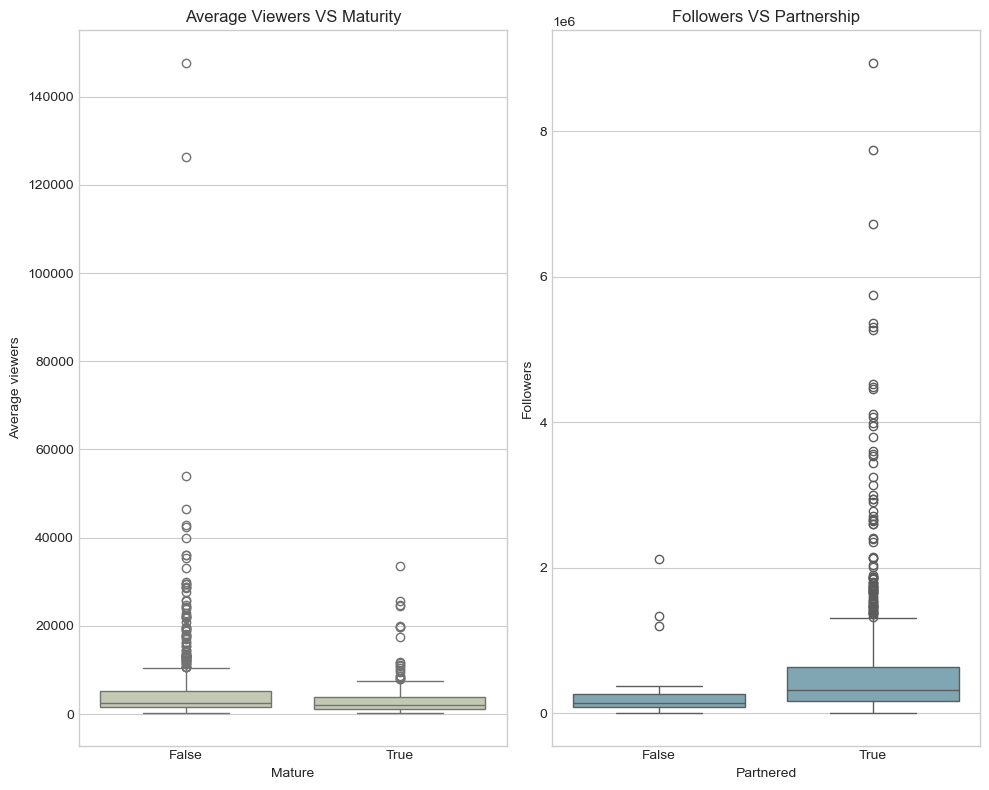

In [54]:
fig, axes = plt.subplots(1,2, figsize=(10,8))
sns.boxplot(data=twitch, x="Mature", y="Average viewers", ax=axes[0], color="#c6ccb0")
sns.boxplot(data=twitch, x="Partnered", y="Followers", ax=axes[1], color="#77aabb")


axes[0].set_title("Average Viewers VS Maturity")
axes[1].set_title("Followers VS Partnership")

plt.tight_layout()
plt.show()

- Box plot Analysis:
  - "Viewers VS Maturity": mature content had ver low number of average viewers compared to kids content, which are the main cause of outliers and skew, 100 of them ranging between 10.000 viewers and 60.000 viewers on average (per kids' channel).
  - "Followers VS Partnership": Streamers who had partnerships gained more followers than those with no partnerships. Many of them had followers far higher than the median. 89 channels had followers from 1 to 8.94 million (per creator).

## Step 2 - Correlation Matrix and Annotated Heatmap

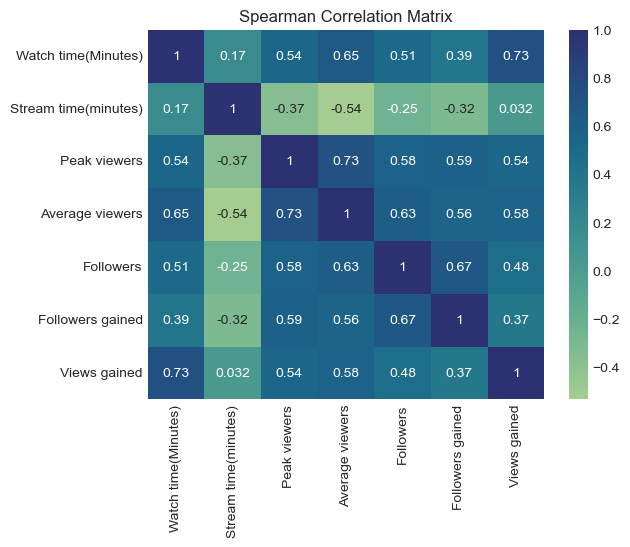

In [55]:
corr = twitch[numeric_cols].corr(method="spearman")
sns.heatmap(corr, cmap="crest", annot=True)
plt.title("Spearman Correlation Matrix")
plt.show()

## Step 3 - Strongest Relationships

- Strongest 3 relationships:
    - Average viewers & Peak viewers | 0.73
    - Views gained & Watch time(mins) | 0.73
    - Followers & Followers gained | 0.63
- Why?
    - Values closer to 1.0/-1.0 can be trusted more because of their closer to perfection relationship.
    - Variables with strong correlation to a target variable are proper candidates for a future model.

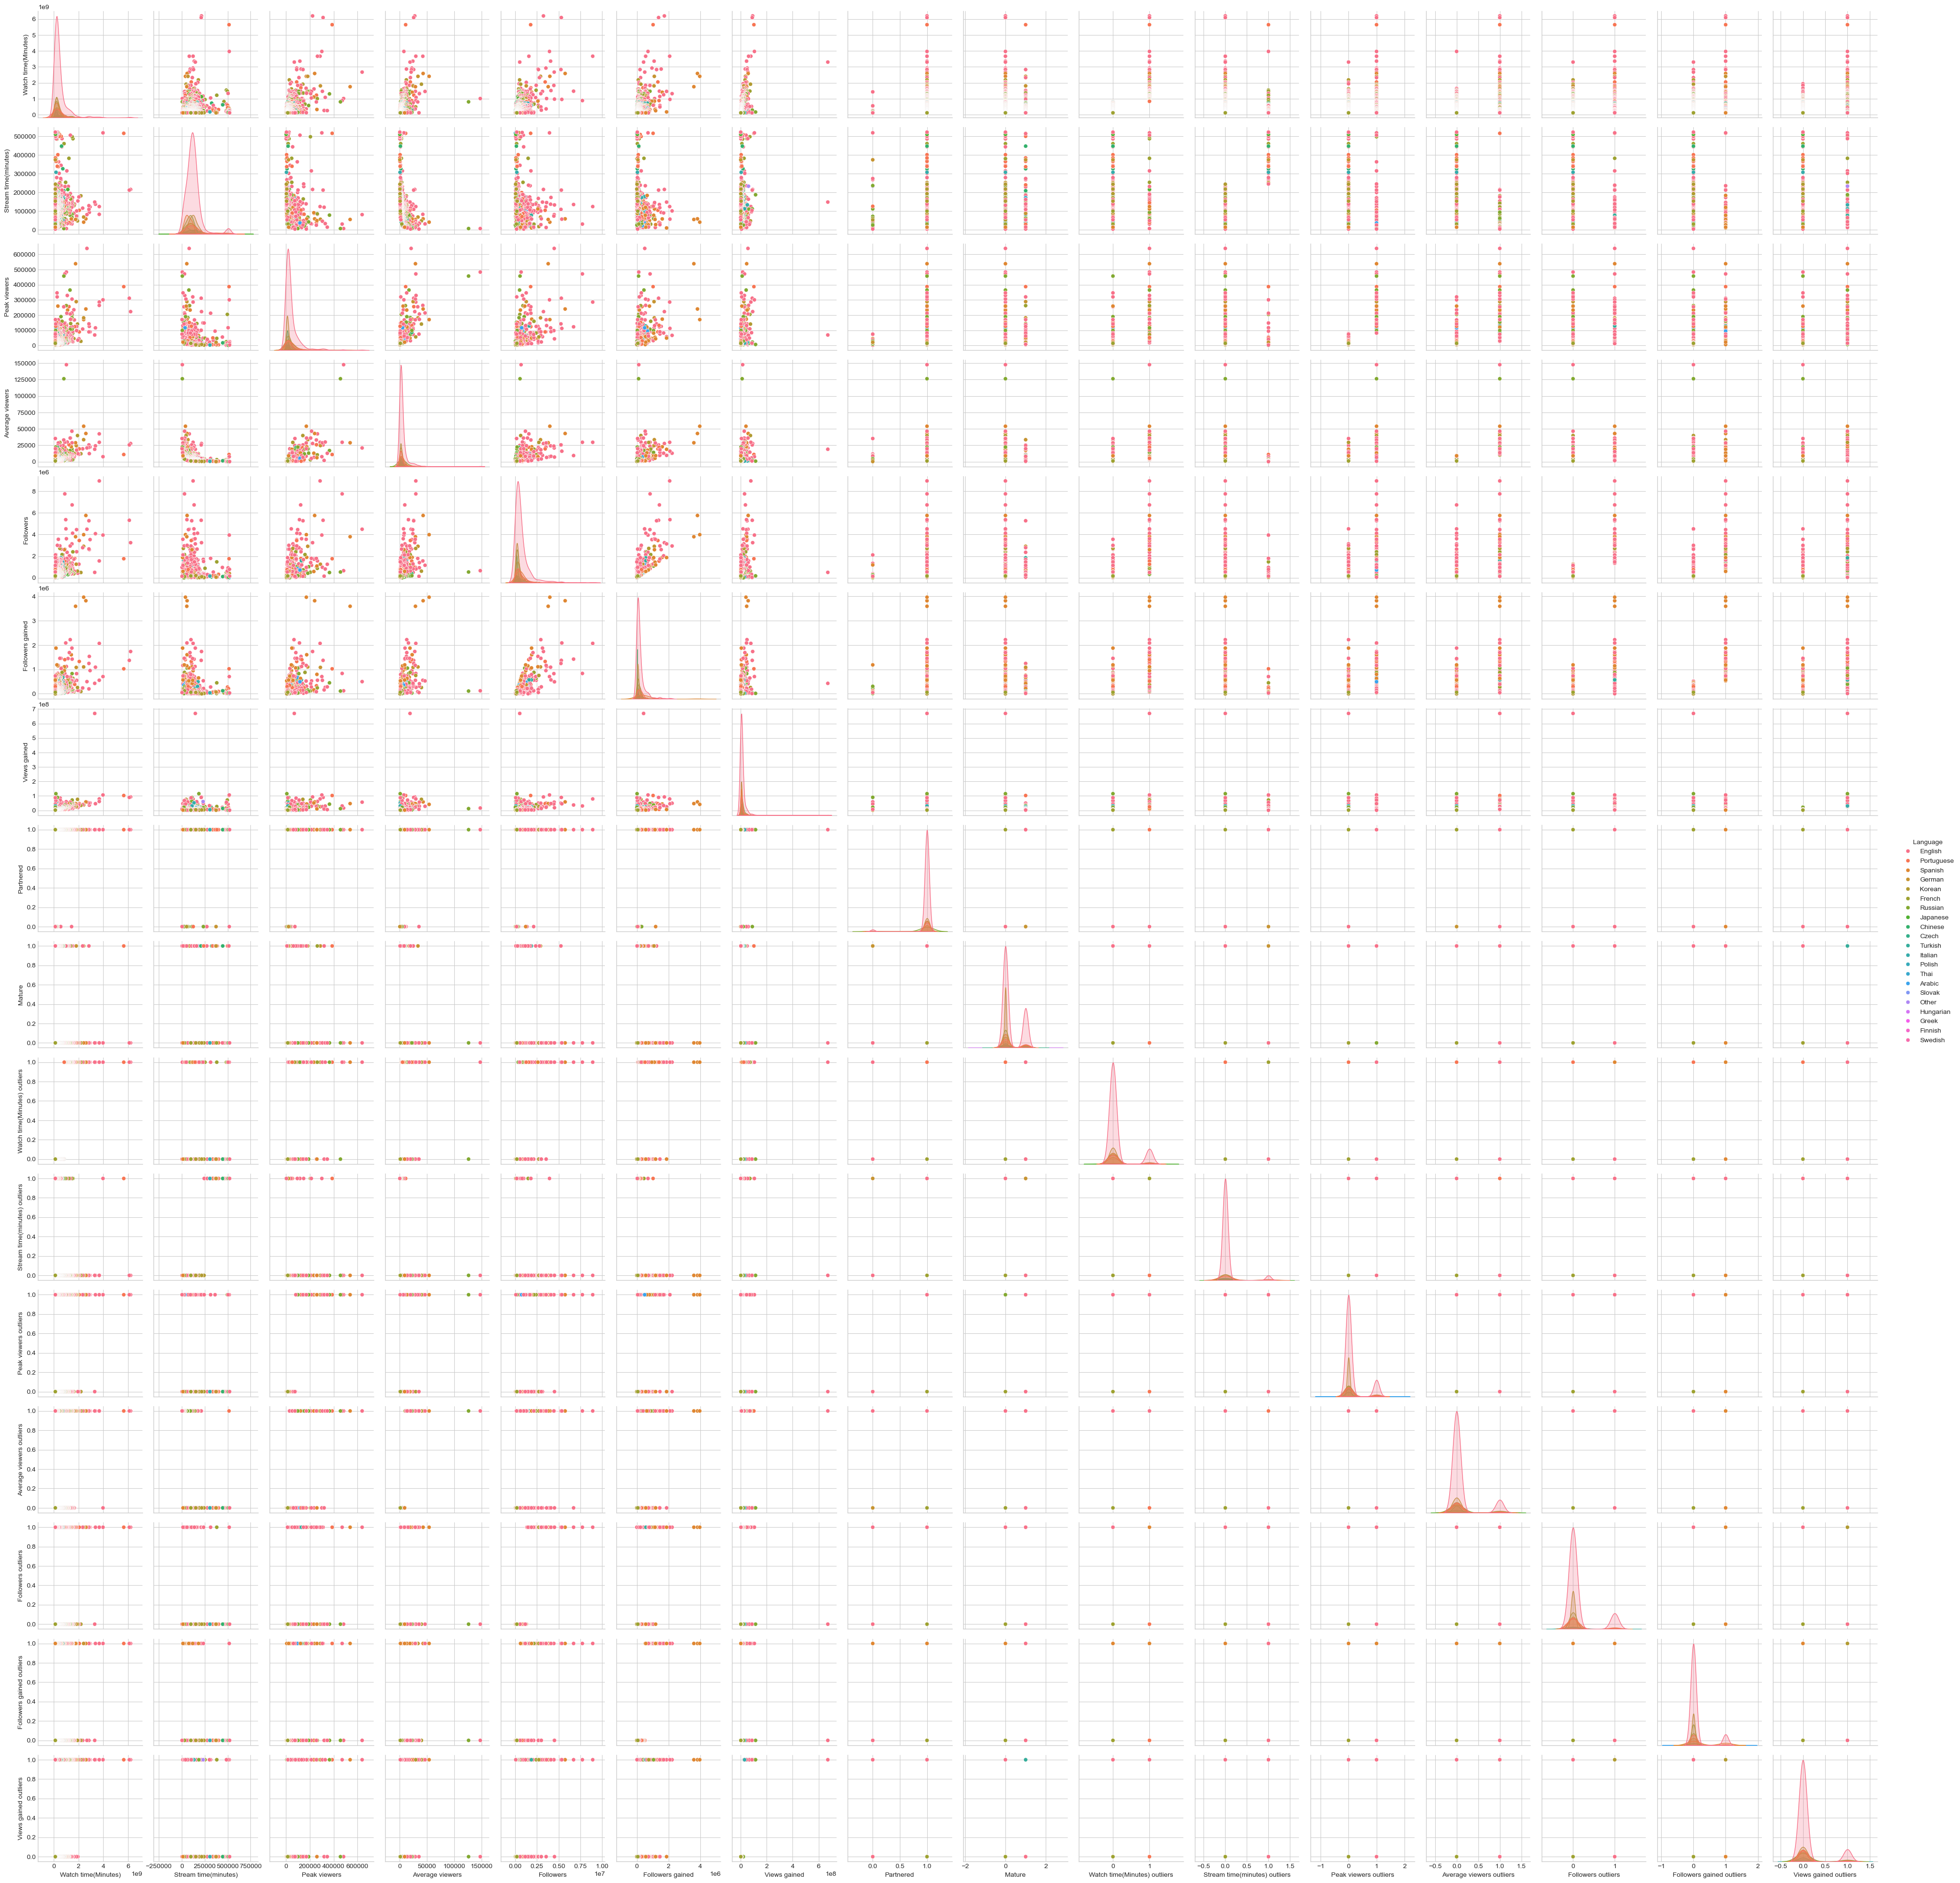

In [56]:
sns.pairplot(twitch, hue="Language")


Observation:
    English was the most common streaming language accross all 1000 channels.